In [ ]:
# FORCme - First Order Reversal Curve, machine-code-execution

# Requires: FORCme.ipynb and forc_funcs.py

# ========================= #
# Project information
# ========================= #

# Code implementation: Maxwell Brown (Institute for Rock Magnetism, University of Minnesota)
# Version: V1.0.1 (beta)
# Date: 07/16/2026
# Based on ideas, mathematics, and code developed by Chris Pike, Andrew Roberts, Richard Harrison, Ramon Egli, Adrian Muxworthy, Josh Feinberg (and others). 
# Part of the RockmagPy coding suite (https://pmagpy.github.io/RockmagPy-notebooks/book/intro.html).
# OpenAI ChatGPT 5.2 assisted in executing the mechanics of the coding.
# 
# Work carried out under NSF Award EAR-2148549.
#
# Please cite as:
# Maxwell Brown (2026), FORCme: Application of machine code and adaptive smoothing within python for the rapid processing of First Order Reversal Curves, https://doi.org/10.5281/zenodo.19635914
# 
# https://github.com/Institute-for-Rock-Magnetism/FORCme 

Segments: 269 | median len=271 | min=3 | max=399 | >=3 pts=269
Regridded FORCs to common B grid: -1.245→1.095 T (n=157), step=0.015 T
FORC segments provided: 269
FORC segments usable (>=3 finite pts): 266
Inferred dHa ≈ 0.015 T, Ha: -1.245→1.095 (n=157)
Inferred dHb ≈ 0.005 T, Hb: -1.245→0.08 (n=266)
M_grid shape: (266, 157)


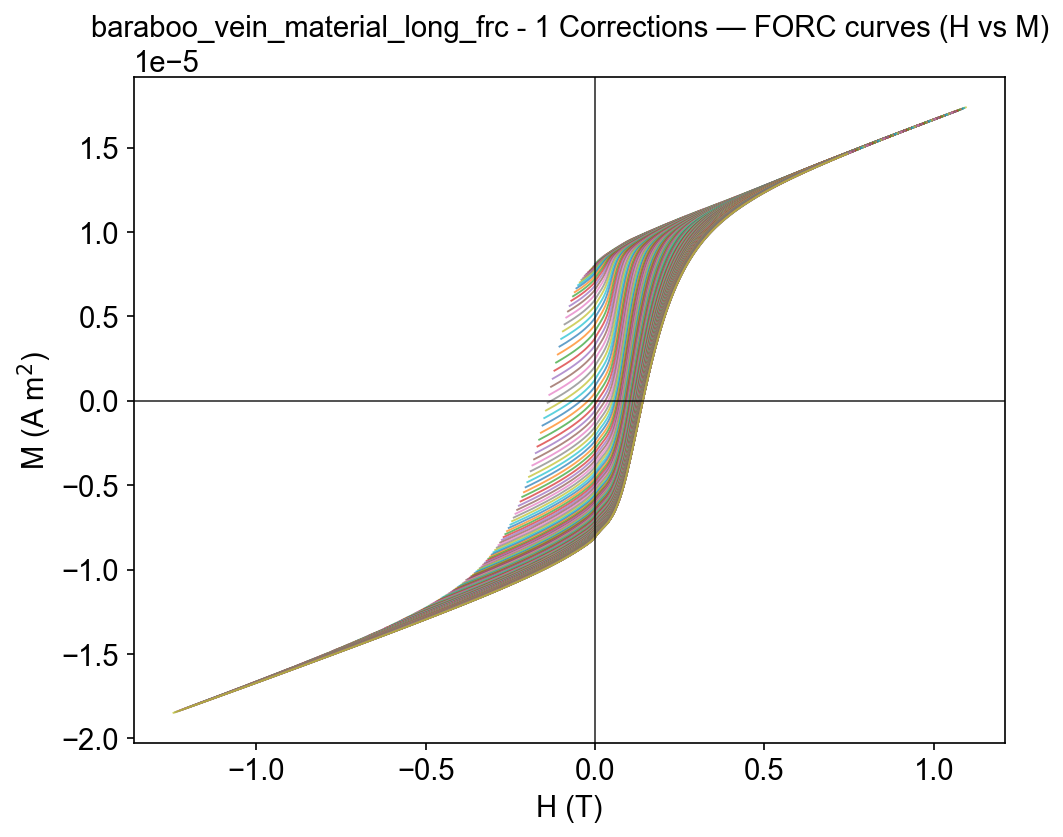

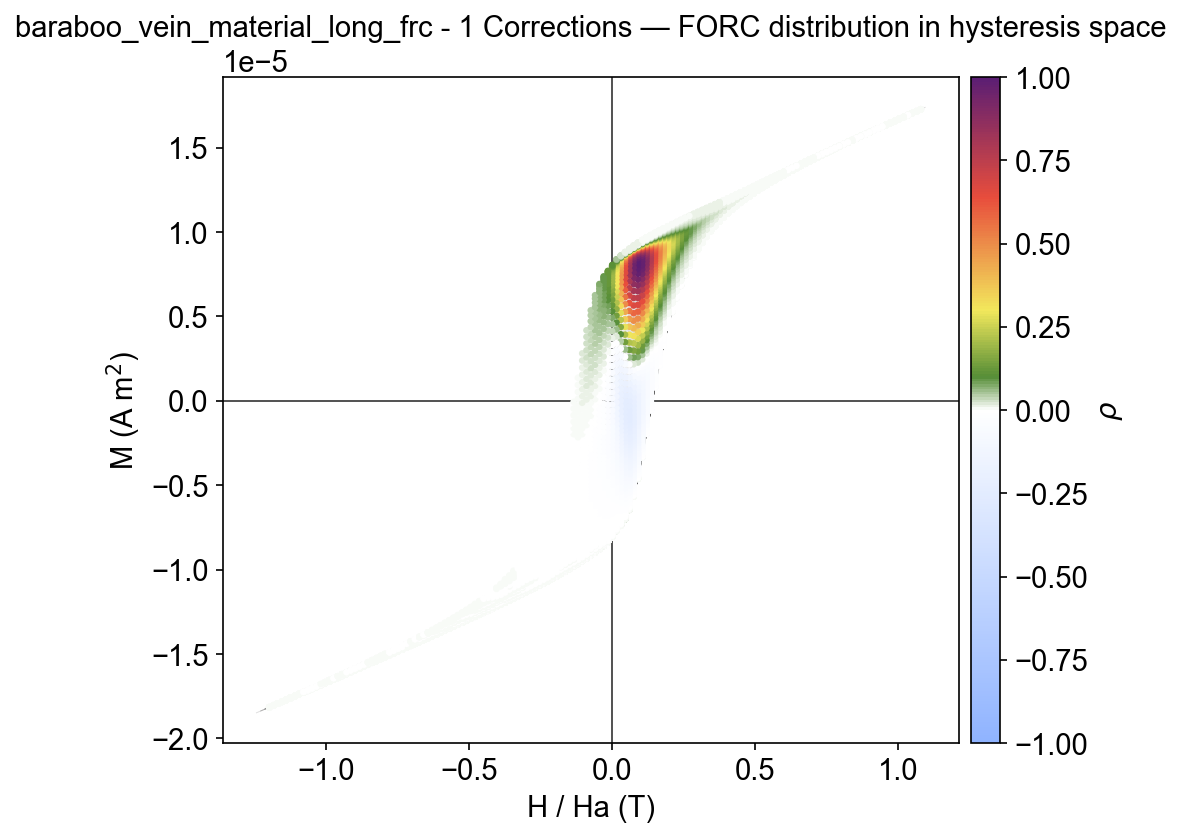

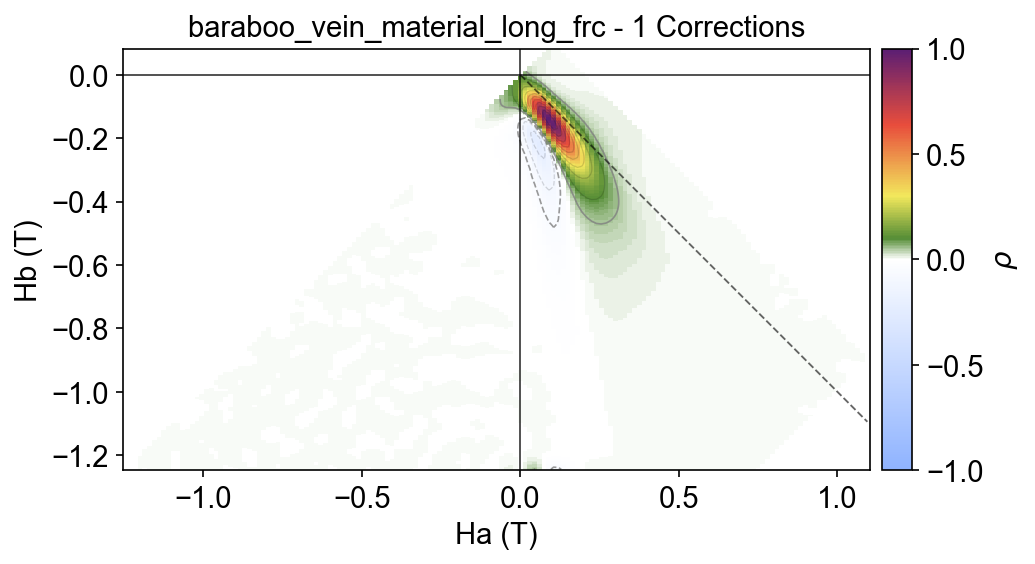

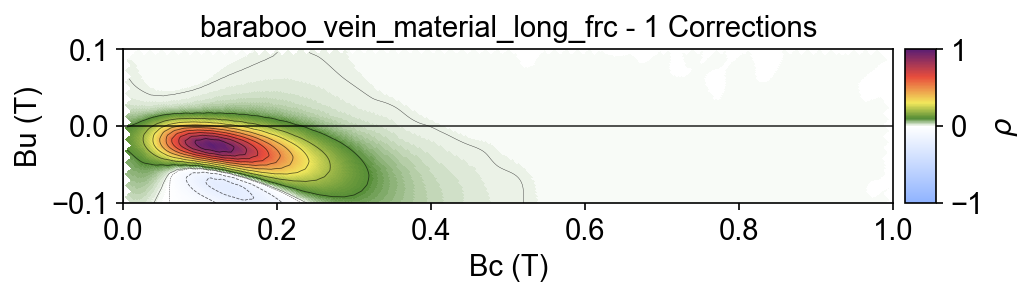

Saved: FORC_figures\baraboo_vein_material_long_frc - 1 Corrections_FORC.png


WindowsPath('FORC_figures/baraboo_vein_material_long_frc - 1 Corrections_FORC.png')

In [ ]:

import numpy as np
import importlib
import forc_funcs as ff             # place stable version in PmagPy/pmagpy and make sure that your operating system has this directory in its python distribution PATH
importlib.reload(ff)

ff.set_plot_style("Arial")          # Change to whatever font is preffered for plotting

# =============================== #
# 1. FORC Plotting
# =============================== #
out = ff.run_forc_pipeline(
    mode = "i",                         # Select the mode of processing. "i" = individual file; "b" = batch processing; "s" = stacked processing.
    file_type = "*.txt",                # Default is to look for all .txt files in path directory. 
    path = r" ",                        # If in individual mode enter the file name with extension. If in batch or stack mode enter the folder to read the files from.
    
    # --- Stack setup (when mode set "s") ---
    stack_method = "median",            # Set to mean or median. Median is preferred as less sensitive to outliers

    # --- Allow regridding if data not from a Lake Shore VSM regridded file or to maintain consistency in analysis sample-to-sample ---
    do_regrid = True,               # Turn regridded on (True) or off (False).
    B_step = 0.001,                 # Default is 1 mT. Regridding below the measurement increment can result in artifacts and is not advised.
    regrid_method = "linear",       # or "pchip" (needs scipy) - can change the interpolation method.
    regrid_extrapolate = False,     # False is likely suitable in most cases.

    # --- smoothing controls ---
    smooth_strength = 1.0,          # A multiplier for the 
    min_pts_strength = 1.0,         # See documentation for explanation of the minimum points expander within the LOESS framework (default is fine for most cases)

    # --- plotting toggles ---
    color_scale_version=2,          # Choose from one of three colorscales

    show_contours=True,             # Choose whether to add 10% rho contours and a 1% contour trace
    
    plot_hyst=True,                 # Choose whether to plot the raw loops on a hysteresis plot
    plot_fraction = 1.0,            # Choose the % of curves to plot

    plot_hyst_dist=True,            # Plot FORC in hystersis loop space
    
    plot_hbha=True,                 # optional Hb–Ha plot - unrotated FORC space

    # --- axis limits (in T) ---
    Hu_min = None,                  # change the Hu min value (Hu_max must also be changed) - defaults are bound by FORC file header - often useful to increase the negative area on the plot
    Hu_max = None,                  # change Hu max value
    Hc_min = None,                  # change Hc min value
    Hc_max = None,                  # change Hc max value 

    # --- first/last point replace ---
    replace_first = False,           # True is a default of 1, False applies no correction, an integer selects more points to remove.
    replace_last = False,            # As above

    # --- lower-branch subtraction ---
    do_lower_branch_subtract = False,         # default OFF, but commonly employed
    plot_lower_subtracted_hyst = False,      # only used if do_lower_branch_subtract=True

    # --- color scaling behavior for FORC diagrams ---
    normalize_to_unit = True,               # plots rho normalized to [-1, +1] with 0 white
    pct = 100,                              # percentile used to set the normalization scale - can truncate to "saturate" the higher values of rho

    # --- Image controls ---
    dpi = 150,                             # Display resolution. Change depending on screen resolution and size. Default (None) is 120 dpi.
    display_upsample_factor = 2,           # Image upscaling. 0 = no upscale, and upscale increases by 2. This is an image smoothing, not smoothing of the data. Note, resolution at the By axis will be lost with increasing upscaling.
    export_dpi = 600                       # Change resolution for exported .png. Default (None) is 300 dpi. 
)

ff.export_current_figure_from_out(out)

In [ ]:
# =============================== #
# 2. Profile Plotting - AUTOMATIC
# =============================== #

# The code finds the location of the peak rho value in Bc and Bu and creates vertical and horizontal profiles through those values.

ff.plot_auto_forc_profiles(
    out,
    smooth_sigma_bins=4.0,      # Changes the bin size used for creating the profiles in mT
    export_dpi = 300,           # Changes the resolution of the png to export.
)

In [ ]:
# =============================== #
# 3. Profile Plotting - CUSTOM
# =============================== #

# Select your own Bu and Bc values for horizontal and vertical profile. Sometimes the feature of interest is not at the location of the peak rho value.

ff.plot_custom_forc_profiles(
    out,                                # Investigate a particular profile by entering out[0], out[1], out[2], etc
    user_Bu= 0.0297,                    # Enter custom horizontal profile Bu value in T
    user_Bc= 1.7,                       # Enter custom vertical profile Bc value in T
    smooth_sigma_bins=4.0,              # Changes the bin size used for creating the profiles in mT
    export_dpi=300,                     # Changes the resolution of the png to export.
    return_data=False,
)